# Proyecto Módulo 8 – Clasificador Inteligente de Imágenes de Ropa (PyTorch)

Este notebook replica la estructura del proyecto con **PyTorch**:
1. Red neuronal densa simple (clasificación binaria).
2. Discusión de arquitecturas (densa vs convolutiva).
3. Implementación de modelo denso para Fashion-MNIST.
4. Implementación de CNN para Fashion-MNIST y comparación.

Dataset: Fashion-MNIST (28x28, 10 clases de ropa).

In [1]:
# pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

class_names = [
    'Camiseta/top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
    'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín'
]

len(train_dataset), len(test_dataset)

(60000, 10000)

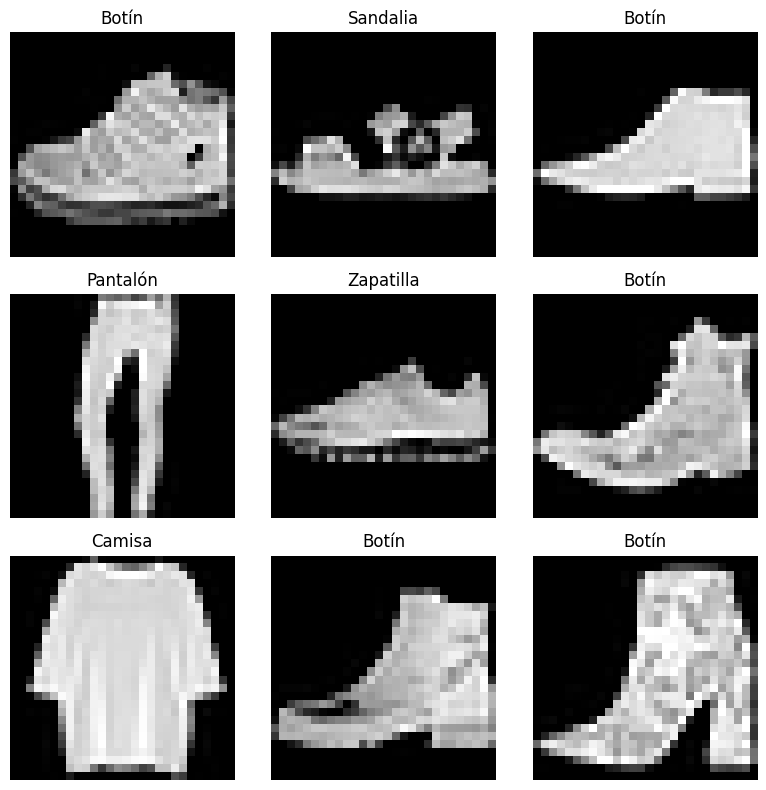

In [3]:
batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
indices_train_bin = [i for i, (_, y) in enumerate(train_dataset) if y in (7, 9)]
indices_test_bin = [i for i, (_, y) in enumerate(test_dataset) if y in (7, 9)]

train_bin = Subset(train_dataset, indices_train_bin)
test_bin = Subset(test_dataset, indices_test_bin)

train_loader_bin = DataLoader(train_bin, batch_size=256, shuffle=True)
test_loader_bin = DataLoader(test_bin, batch_size=256, shuffle=False)

len(train_bin), len(test_bin)

(12000, 2000)

## Lección 1 – Red densa binaria en PyTorch

Problema: distinguir entre **Zapatilla (7)** y **Botín (9)** usando una red densa simple.

- Entrada: imagen 28x28 aplanada a vector de 784.
- Capa oculta: 128 neuronas con ReLU.
- Salida: 1 neurona con sigmoide (probabilidad de "zapatilla").

In [5]:
class BinaryDenseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model_bin = BinaryDenseNet().to(device)
criterion_bin = nn.BCELoss()
optimizer_bin = torch.optim.Adam(model_bin.parameters(), lr=1e-3)

model_bin

BinaryDenseNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [6]:
def train_binary(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        labels_bin = (labels == 7).float().unsqueeze(1)
        images, labels_bin = images.to(device), labels_bin.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_bin)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels_bin).sum().item()
        total += labels_bin.size(0)

    return running_loss / total, correct / total


def eval_binary(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            labels_bin = (labels == 7).float().unsqueeze(1)
            images, labels_bin = images.to(device), labels_bin.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels_bin)
            running_loss += loss.item() * images.size(0)
            preds = (outputs >= 0.5).float()
            correct += (preds == labels_bin).sum().item()
            total += labels_bin.size(0)
    return running_loss / total, correct / total

In [7]:
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train_binary(model_bin, train_loader_bin, optimizer_bin, criterion_bin)
    val_loss, val_acc = eval_binary(model_bin, test_loader_bin, criterion_bin)
    print(f"Época {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, acc: {train_acc:.4f} - Test loss: {val_loss:.4f}, acc: {val_acc:.4f}")

Época 1/10 - Train loss: 0.2127, acc: 0.9125 - Test loss: 0.1527, acc: 0.9375
Época 2/10 - Train loss: 0.1426, acc: 0.9455 - Test loss: 0.1273, acc: 0.9530
Época 3/10 - Train loss: 0.1177, acc: 0.9563 - Test loss: 0.1238, acc: 0.9535
Época 4/10 - Train loss: 0.1070, acc: 0.9605 - Test loss: 0.1060, acc: 0.9575
Época 5/10 - Train loss: 0.1029, acc: 0.9607 - Test loss: 0.1048, acc: 0.9580
Época 6/10 - Train loss: 0.0965, acc: 0.9639 - Test loss: 0.1056, acc: 0.9570
Época 7/10 - Train loss: 0.0954, acc: 0.9638 - Test loss: 0.1015, acc: 0.9590
Época 8/10 - Train loss: 0.0891, acc: 0.9656 - Test loss: 0.1028, acc: 0.9595
Época 9/10 - Train loss: 0.0848, acc: 0.9663 - Test loss: 0.0953, acc: 0.9650
Época 10/10 - Train loss: 0.0877, acc: 0.9666 - Test loss: 0.0997, acc: 0.9610


## Lección 3 – Modelo denso para las 10 clases

Ahora definimos una red densa para clasificar las 10 categorías de Fashion-MNIST.

- Dos capas densas con Dropout.
- Salida de 10 neuronas (logits) y pérdida `CrossEntropyLoss`.

In [8]:
class DenseNetMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

model_dense = DenseNetMNIST().to(device)
criterion_dense = nn.CrossEntropyLoss()
optimizer_dense = torch.optim.Adam(model_dense.parameters(), lr=1e-3)

model_dense

DenseNetMNIST(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

In [9]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [10]:
num_epochs = 15
train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_dense, train_loader, optimizer_dense, criterion_dense)
    val_loss, val_acc = eval_epoch(model_dense, test_loader, criterion_dense)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Época {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, acc: {train_acc:.4f} - Test loss: {val_loss:.4f}, acc: {val_acc:.4f}")

Época 1/15 - Train loss: 0.6459, acc: 0.7655 - Test loss: 0.4523, acc: 0.8375
Época 2/15 - Train loss: 0.4376, acc: 0.8427 - Test loss: 0.4073, acc: 0.8541
Época 3/15 - Train loss: 0.4032, acc: 0.8540 - Test loss: 0.3915, acc: 0.8556
Época 4/15 - Train loss: 0.3764, acc: 0.8630 - Test loss: 0.3668, acc: 0.8659
Época 5/15 - Train loss: 0.3595, acc: 0.8696 - Test loss: 0.3658, acc: 0.8704
Época 6/15 - Train loss: 0.3438, acc: 0.8749 - Test loss: 0.3513, acc: 0.8736
Época 7/15 - Train loss: 0.3311, acc: 0.8798 - Test loss: 0.3415, acc: 0.8755
Época 8/15 - Train loss: 0.3210, acc: 0.8817 - Test loss: 0.3587, acc: 0.8728
Época 9/15 - Train loss: 0.3160, acc: 0.8839 - Test loss: 0.3383, acc: 0.8792
Época 10/15 - Train loss: 0.3032, acc: 0.8879 - Test loss: 0.3401, acc: 0.8797
Época 11/15 - Train loss: 0.2993, acc: 0.8898 - Test loss: 0.3277, acc: 0.8836
Época 12/15 - Train loss: 0.2915, acc: 0.8924 - Test loss: 0.3364, acc: 0.8815
Época 13/15 - Train loss: 0.2860, acc: 0.8948 - Test loss: 0.

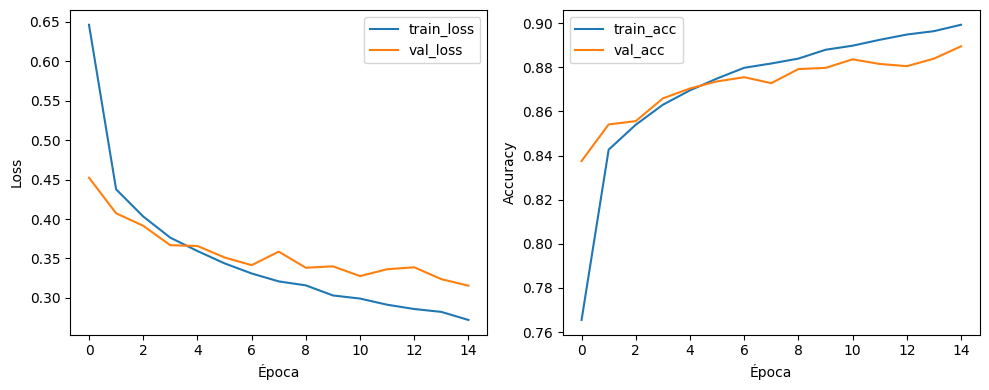

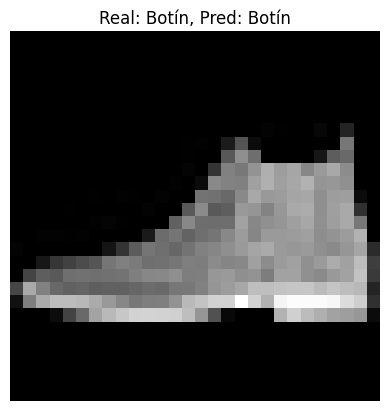

In [11]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train_acc')
plt.plot(val_accs, label='val_acc')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

model_dense.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    outputs = model_dense(images)
    _, preds = torch.max(outputs, 1)

idx = 0
plt.imshow(images[idx].cpu()[0], cmap='gray')
plt.title(f"Real: {class_names[labels[idx]]}, Pred: {class_names[preds[idx]]}")
plt.axis('off')
plt.show()

## Lección 4 – CNN en PyTorch

Definimos una CNN con dos capas convolucionales y pooling, seguida de capas densas.

La idea es comparar su desempeño con el modelo denso anterior.

In [12]:
class CNNMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_cnn = CNNMNIST().to(device)
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

model_cnn

CNNMNIST(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [13]:
num_epochs = 15
cnn_train_losses, cnn_train_accs, cnn_val_losses, cnn_val_accs = [], [], [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_cnn, train_loader, optimizer_cnn, criterion_cnn)
    val_loss, val_acc = eval_epoch(model_cnn, test_loader, criterion_cnn)

    cnn_train_losses.append(train_loss)
    cnn_train_accs.append(train_acc)
    cnn_val_losses.append(val_loss)
    cnn_val_accs.append(val_acc)

    print(f"[CNN] Época {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, acc: {train_acc:.4f} - Test loss: {val_loss:.4f}, acc: {val_acc:.4f}")

[CNN] Época 1/15 - Train loss: 0.7170, acc: 0.7398 - Test loss: 0.4651, acc: 0.8281
[CNN] Época 2/15 - Train loss: 0.4630, acc: 0.8327 - Test loss: 0.3837, acc: 0.8584
[CNN] Época 3/15 - Train loss: 0.3988, acc: 0.8577 - Test loss: 0.3497, acc: 0.8756
[CNN] Época 4/15 - Train loss: 0.3578, acc: 0.8725 - Test loss: 0.3209, acc: 0.8813
[CNN] Época 5/15 - Train loss: 0.3335, acc: 0.8813 - Test loss: 0.3156, acc: 0.8862
[CNN] Época 6/15 - Train loss: 0.3128, acc: 0.8883 - Test loss: 0.2925, acc: 0.8963
[CNN] Época 7/15 - Train loss: 0.2949, acc: 0.8936 - Test loss: 0.2820, acc: 0.8987
[CNN] Época 8/15 - Train loss: 0.2800, acc: 0.8999 - Test loss: 0.2777, acc: 0.8972
[CNN] Época 9/15 - Train loss: 0.2675, acc: 0.9048 - Test loss: 0.2717, acc: 0.9004
[CNN] Época 10/15 - Train loss: 0.2565, acc: 0.9082 - Test loss: 0.2533, acc: 0.9089
[CNN] Época 11/15 - Train loss: 0.2452, acc: 0.9114 - Test loss: 0.2658, acc: 0.9054
[CNN] Época 12/15 - Train loss: 0.2377, acc: 0.9138 - Test loss: 0.2498, a

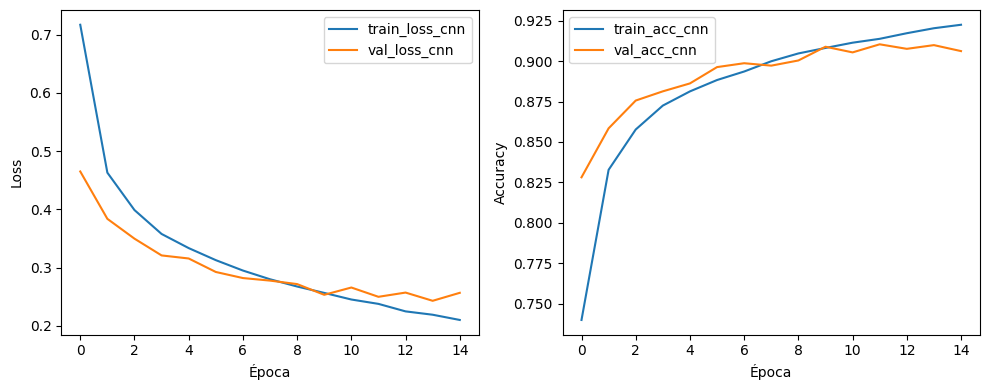

Accuracy final denso vs CNN (test): 0.8895 vs 0.9062


In [14]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_train_losses, label='train_loss_cnn')
plt.plot(cnn_val_losses, label='val_loss_cnn')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_train_accs, label='train_acc_cnn')
plt.plot(cnn_val_accs, label='val_acc_cnn')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print('Accuracy final denso vs CNN (test):', val_accs[-1], 'vs', cnn_val_accs[-1])